In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [31]:
import h5ify

In [32]:
outdir = '../../data/inference/pixelpop/hmc/m1m2t1t2/nb40x40x10x10-var1-chain4-margsig'

In [33]:
result = h5ify.load(f'{outdir}/chain_0_samples.h5')

In [34]:
from pixelpop.result import create_popsummary
from numpyro.distributions import Delta

mmin = 3
mmax = 300

minima={
    'log_mass_1': np.log(mmin),
    'log_mass_2': np.log(mmin),
    'cos_tilt_1': -1.0,
    'cos_tilt_2': -1.0,
}
maxima={
    'log_mass_1': np.log(mmax),
    'log_mass_2': np.log(mmax),
    'cos_tilt_1': 1.0,
    'cos_tilt_2': 1.0,
}

create_popsummary(
    result,
    'result',
    ['log_mass_1', 'log_mass_2', 'cos_tilt_1', 'cos_tilt_2'],
    ['redshift'],
    popsummary_path=f'{outdir}/popsummary',
    datadir='/n/home03/newolfe/projects/tilts-and-kicks/data',
    minima=minima,
    maxima=maxima,
    priors=dict(max_z=([2.3], Delta)),
    lower_triangular=True,
    bins=[40, 40, 10, 10]
)

Using default prior lamb = Uniform(-2, 10) in redshift model
Using custom prior max_z = Delta(2.3) in redshift model


Could not load run metadata, skipping.


/n/home03/newolfe/.conda/envs/just-for-kicks/lib/python3.11/site-packages/pixelpop/result/save_popsummary.py:232: RuntimeWarning: divide by zero encountered in log
  posterior['merger_rate_density'] = np.log(axes_tril(np.exp(posterior['merger_rate_density']), axes=(1,2)))
Computing cos_tilt_2 marginals: 100%|██████████| 740/740 [00:02<00:00, 273.56it/s]


cos_tilt_1 (740, 11)
cos_tilt_2 (740, 11)
Saving redshift rates on grids...


  0%|          | 0/740 [00:00<?, ?it/s]


Could not save redshift rates on grids, skipping...


In [35]:
from popsummary.popresult import PopulationResult

result = PopulationResult(f'{outdir}/popsummary/result.h5')

In [36]:
bins, rate = result.get_rates_on_grids('joint_pixelpop_rate')

bins = [ b.reshape(41, 41, 11, 11) for b in bins ]
rate = rate.reshape((740, 40, 40, 10, 10))

In [37]:
import numpy as np
from scipy.special import logsumexp

log_dct = np.log(0.2)

only_masses = logsumexp(np.log(rate), axis=(3, 4)) + log_dct

/tmp/ipykernel_2375981/1959990759.py:6: RuntimeWarning: divide by zero encountered in log
  only_masses = logsumexp(np.log(rate), axis=(3, 4)) + log_dct


In [38]:
med = np.median(only_masses, axis=0)

Text(0, 0.5, '(mass_2 / Msun)')

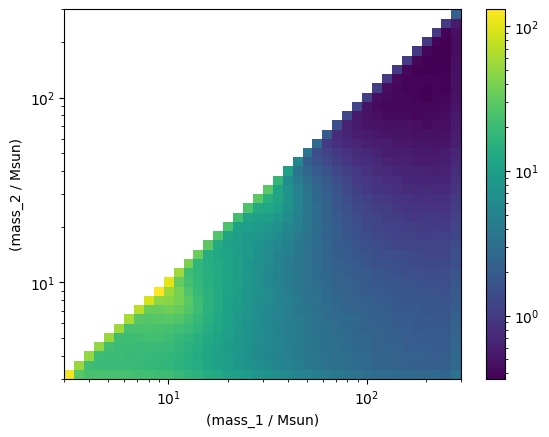

In [39]:
fig, ax = plt.subplots()
im = ax.pcolormesh(
    np.exp(bins[0][:, :, 0, 0]),
    np.exp(bins[1][:, :, 0, 0]),
    np.exp(med),
    norm='log'
)
ax.loglog();
plt.colorbar(im);

ax.set_xlabel('(mass_1 / Msun)')
ax.set_ylabel('(mass_2 / Msun)')

In [24]:
np.exp(bins[0][11, 0, 0, 0])

np.float64(10.644401677007263)

In [47]:
np.exp(bins[0][23, 0, 0, 0])


np.float64(42.37612633868263)

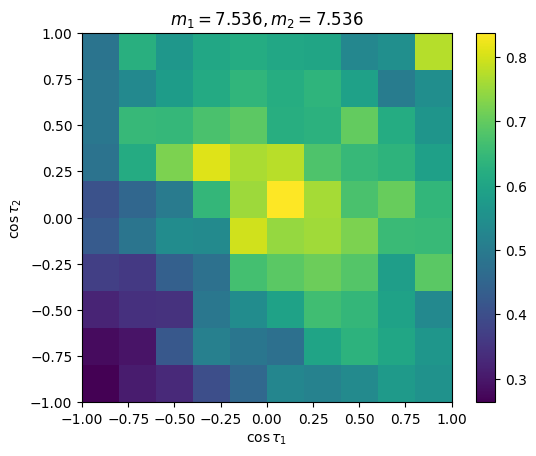

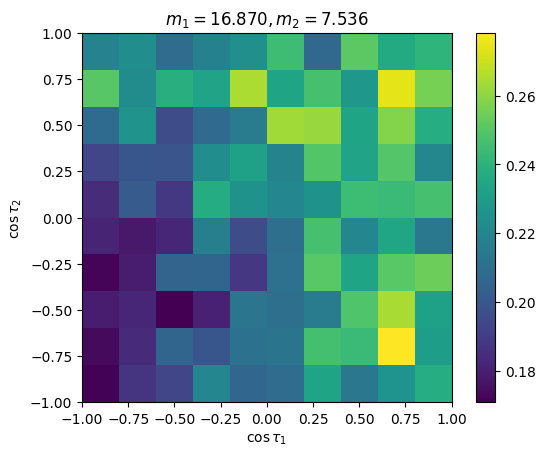

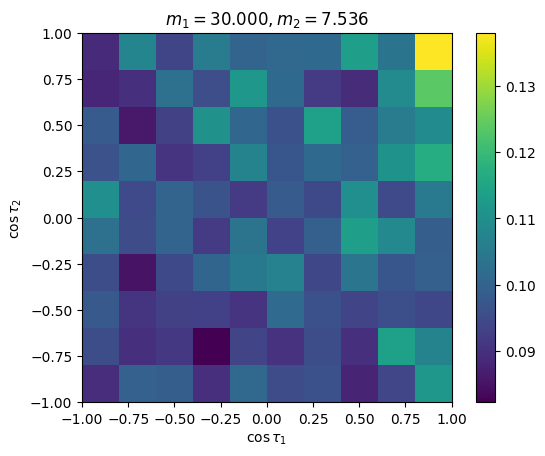

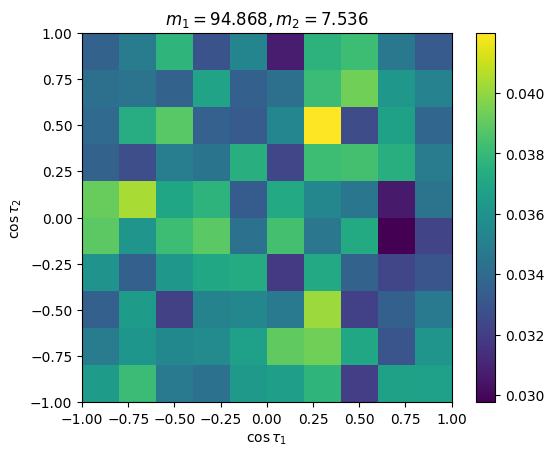

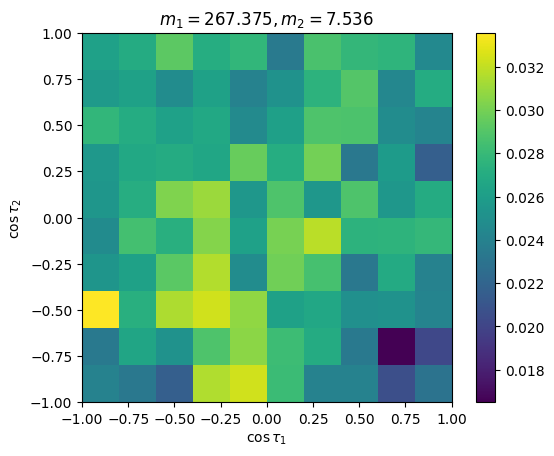

In [40]:
import numpy as np

#midx = 11 # ~10.6 Msun

for midx in [8, 15, 20, 30, 39]:
    m2idx = 8

    rate_ct = rate[:, midx, m2idx]
    median_rate_ct = np.median(rate_ct, axis=0)

    fig, ax = plt.subplots()
    ax.set_title(rf'$m_1 = {np.exp(bins[0][midx,0,0,0]):.3f}, m_2 = {np.exp(bins[1][0,m2idx,0,0]):.3f}$')
    im = ax.pcolormesh(
        bins[2][midx, m2idx],
        bins[3][midx, m2idx],
        median_rate_ct
    )
    ax.set_box_aspect(1)
    ax.set_xlabel(r'$\cos \tau_1$')
    ax.set_ylabel(r'$\cos \tau_2$')
    plt.colorbar(im);

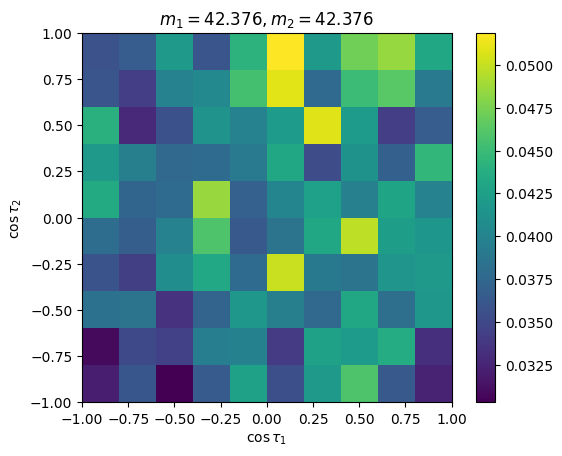

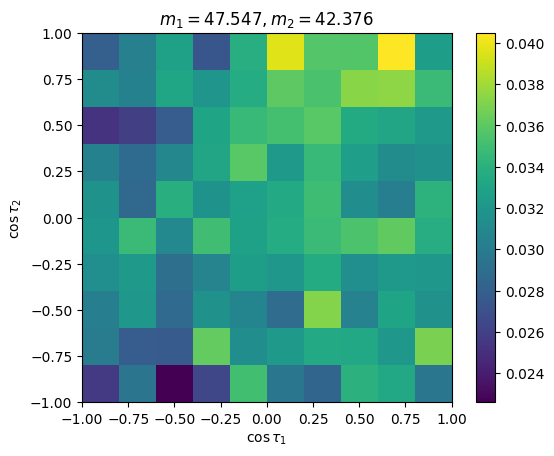

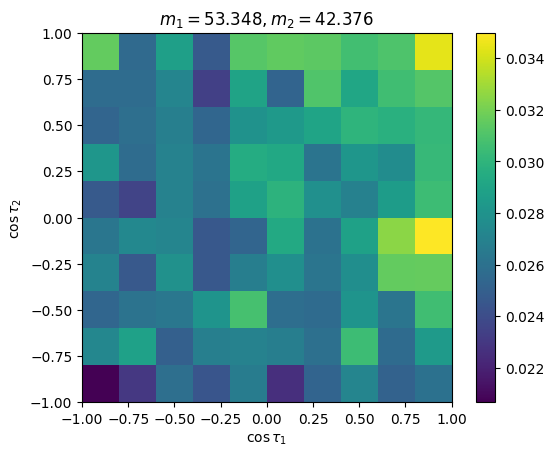

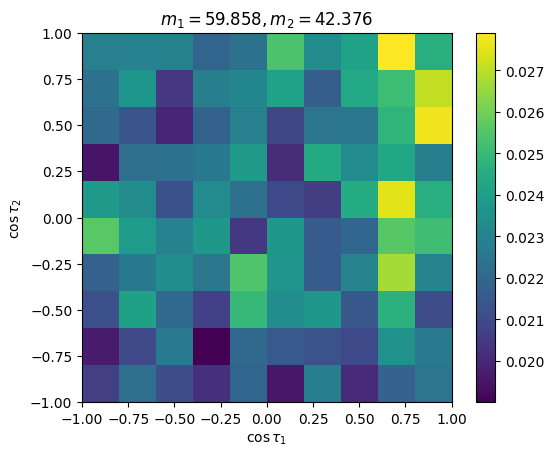

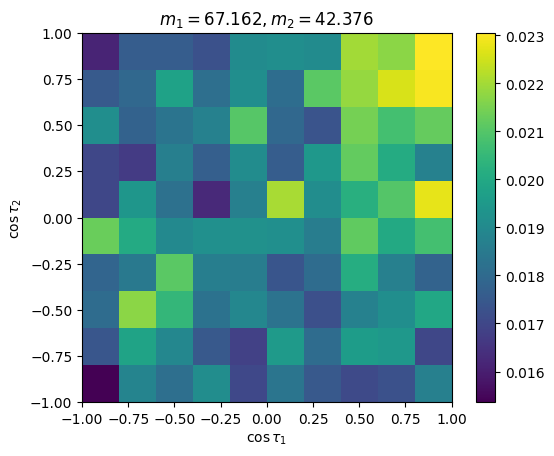

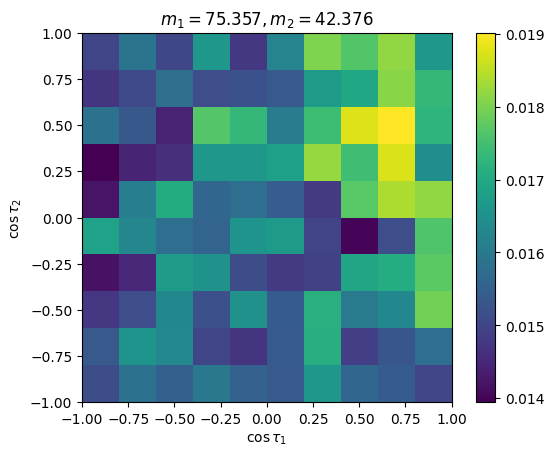

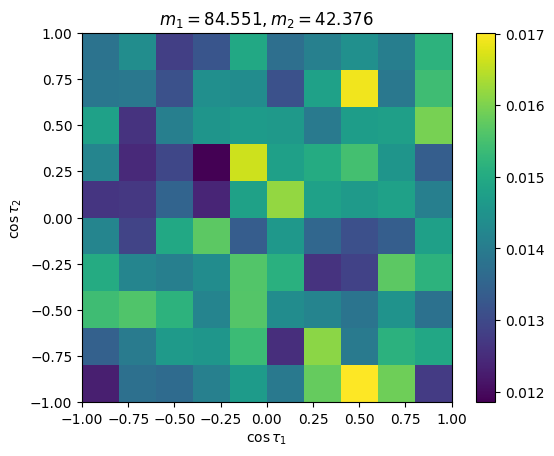

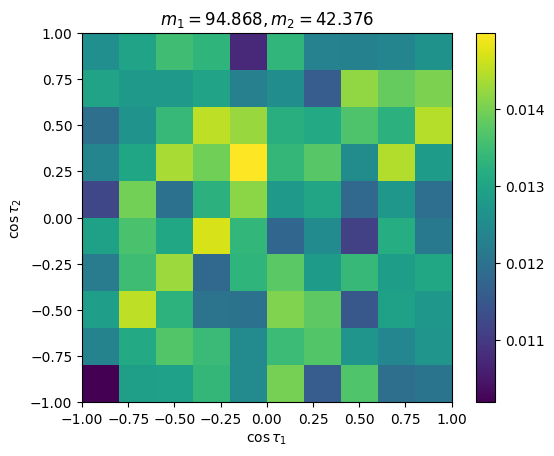

In [48]:
import numpy as np
np.exp(bins[0][11, 0, 0, 0])

#midx = 11 # ~10.6 Msun

for midx in [23, 24, 25, 26, 27, 28, 29, 30]:
    m2idx = 23

    rate_ct = rate[:, midx, m2idx]
    median_rate_ct = np.median(rate_ct, axis=0)

    fig, ax = plt.subplots()
    ax.set_title(rf'$m_1 = {np.exp(bins[0][midx,0,0,0]):.3f}, m_2 = {np.exp(bins[1][0,m2idx,0,0]):.3f}$')
    im = ax.pcolormesh(
        bins[2][midx, m2idx],
        bins[3][midx, m2idx],
        median_rate_ct
    )
    ax.set_box_aspect(1)
    ax.set_xlabel(r'$\cos \tau_1$')
    ax.set_ylabel(r'$\cos \tau_2$')
    plt.colorbar(im);

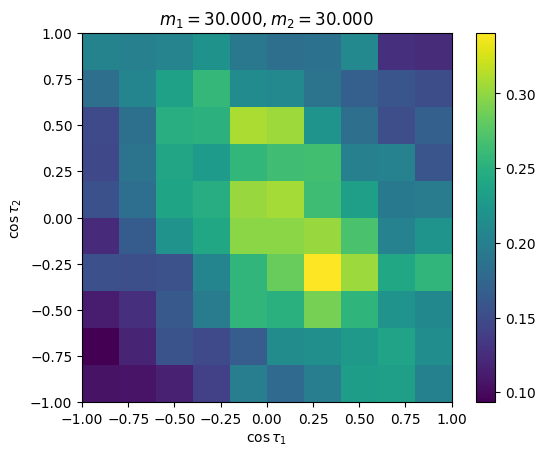

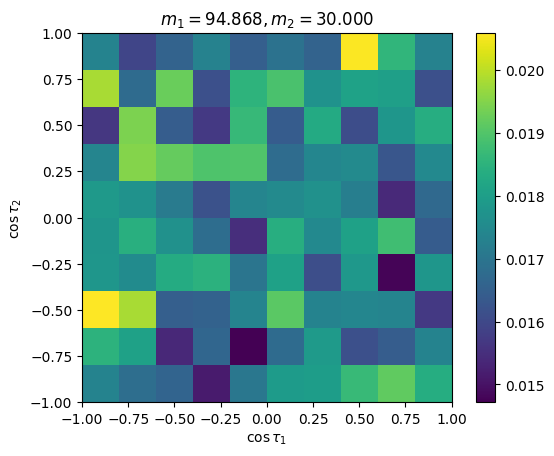

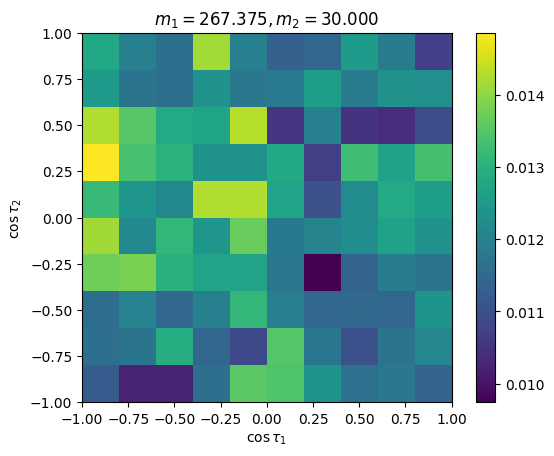

In [42]:
import numpy as np

#midx = 11 # ~10.6 Msun

for midx in [20, 30, 39]:
    m2idx = 20

    rate_ct = rate[:, midx, m2idx]
    median_rate_ct = np.median(rate_ct, axis=0)

    fig, ax = plt.subplots()
    ax.set_title(rf'$m_1 = {np.exp(bins[0][midx,0,0,0]):.3f}, m_2 = {np.exp(bins[1][0,m2idx,0,0]):.3f}$')
    im = ax.pcolormesh(
        bins[2][midx, m2idx],
        bins[3][midx, m2idx],
        median_rate_ct
    )
    ax.set_box_aspect(1)
    ax.set_xlabel(r'$\cos \tau_1$')
    ax.set_ylabel(r'$\cos \tau_2$')
    plt.colorbar(im);

In [ ]:
n

In [ ]:
import numpy as np

#midx = 11 # ~10.6 Msun

for midx in [20, 30, 39]:
    m2idx = 20

    rate_ct = rate[:, midx, m2idx]
    median_rate_ct = np.median(rate_ct, axis=0)

    fig, ax = plt.subplots()
    ax.set_title(rf'$m_1 = {np.exp(bins[0][midx,0,0,0]):.3f}, m_2 = {np.exp(bins[1][0,m2idx,0,0]):.3f}$')
    im = ax.pcolormesh(
        bins[2][midx, m2idx],
        bins[3][midx, m2idx],
        median_rate_ct
    )
    ax.set_box_aspect(1)
    ax.set_xlabel(r'$\cos \tau_1$')
    ax.set_ylabel(r'$\cos \tau_2$')
    plt.colorbar(im);